In [ ]:
from typing import List,TypedDict
import re

import pypdf
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS

from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START,END
from pydantic import BaseModel
from dotenv import load_dotenv

from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()

e:\Machine Learning and Data Science\Advanced-RAGS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

### Load the documents

In [ ]:
docs = (
    PyPDFLoader("documents/oops.pdf").load()
)

### Chunk Creation

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=100).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode('utf-8','ignore').decode('utf-8','ignore')

In [5]:
len(chunks)

62

### Embeddings

In [6]:
embeddings = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')
vector_stores = FAISS.from_documents(chunks,embeddings)

### Retriever

In [7]:
retriever = vector_stores.as_retriever(search_type='similarity',search_kwargs={"k":1})

### LLM

In [8]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

### Threshold

In [9]:
UPPER_TH = 0.7
LOWER_TH = 0.3

## State

In [23]:
class State(TypedDict):

    question : str
    docs : List[Document]

    good_docs : List[Document]
    verdict : str
    reason : str

    strips : List[str]
    kept_strips : List[str]

    refined_context : str

    web_docs : List[Document]

    web_query: str

    answer : str

## Graph Nodes

#### Retriever Node

In [24]:
def retriever_node(state: State):
    question = state['question']
    return {'docs': retriever.invoke(question)}

### Score Based Doc Eval

In [25]:
class DocEvalScore(BaseModel):
    score : int
    reason : str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',   
            "You evaluate RAG retrieval.\n"
            "Given a question and ONE chunk, return relevance score [0–1].\n"
            "1 = sufficient to answer, 0 = irrelevant.\n"
            "Be conservative.\n"
            "Return JSON:"
        ),
        ("human", "Question: {question}\n\nchunk: {chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State):

    q = state['question']

    scores : List[float] = []
    reasons : List[str] = []
    good : List[Document] = []

    for d in state['docs']:

        out = doc_eval_chain.invoke({'question':q,"chunk": d.page_content}) 

        scores.append(out.score)
        reasons.append(out.reason)

        if out.score > LOWER_TH:

            good.append(d)

    
    # Correct
    if any(s > UPPER_TH for s in scores):
        return {
            'verdict': "CORRECT",
            'good_docs': good,
            "reason": "At least on doc greater than Upper threshold"
        }
    
    # incorrect
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            'good_docs': [],
            'verdict': "INCORRECT",
            'reason': "No one scores greater than lowerr threshold"
        }
    
    # aAmbiguous

    return{
        'good_docs': good,
        'verdict': "AMBIGUOUS",
        'reason': f"Mixed Ambiguous"
    }



### Knowledge Refinement

In [26]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


class KeepOrNot(BaseModel):
    keep : bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Decide if a sentence helps answer the question. Return JSON"
        ),
        ("human", "Q:{question}\nS:{sentence}")
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrNot)

def refine(state: State):

    if state.get('verdict')  == "CORRECT":
        context = "\n\n".join(d.page_content for d in state['good_docs']).strip()
    else:
        context = "\n\n".join(d.page_content for d in state['web_docs']).strip()

    strips = decompose_to_sentences(context)

    kept_strips : List[str] = []

    for i,s in enumerate(strips): # for least use of API 
        if i >= 2:
            break
        
        if filter_chain.invoke({'question':state['question'],'sentence':s}).keep:
            kept_strips.append(s)

    refined_context = "\n".join(kept_strips).strip()

    return {
        'strips': strips,
        'kept_strips': kept_strips,
        'refined_context': refined_context    
    }

## Web Search Node

### Here Query Rewrite for searching purpose and better searching

In [27]:
class WebQuery(BaseModel):

    query : str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the query in better way that efficient for searching Do not answer the query.\n"
        ),
        ("human","Question: {question}")
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({'question':state['question']})
    return {'web_query':out.query }

In [28]:
tavily = TavilySearchResults(max_results=1)

def web_search_node(state: State):

    q = state['web_query'] or state['question']

    results = tavily.invoke({'query':q})


    web_docs = []

    for r in results or []:
        title = r.get('title',"")
        url = r.get('url',"")
        content = r.get('content',"") or r.get("snippet","")

        text = f"TITLE: {title} \n URL: {url} \n CONTENT: \n {content}"

        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))


    return {"web_docs": web_docs}


### Generate Answer

In [29]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are Helpful ML tutor. Answer only using the provided refined bullets.\n"
            "If the bullets are empty or insufficient say: I don't Know based on the provided book"
        ),
        (
            "human","Question: {question}\n\nRefined Context \n {refined_context}"
        )
    ]
)

def generate(state: State):

    q = state['question']
    content = state['refined_context']

    answer = (answer_prompt | llm).invoke({'question':q,'refined_context':content})

    return {'answer':answer.content}

In [32]:
def ambiguous_node(state: State):
    return {'answer': f"Ambiguous: {state['reason']}"}


def route_after_eval(state: State):

    if state['verdict'] == "CORRECT":
        return 'refine'
    elif state['verdict'] == "INCORRECT":
        return "rewrite_query"
    else:
        return "ambiguous_node"
    

## Graph Build

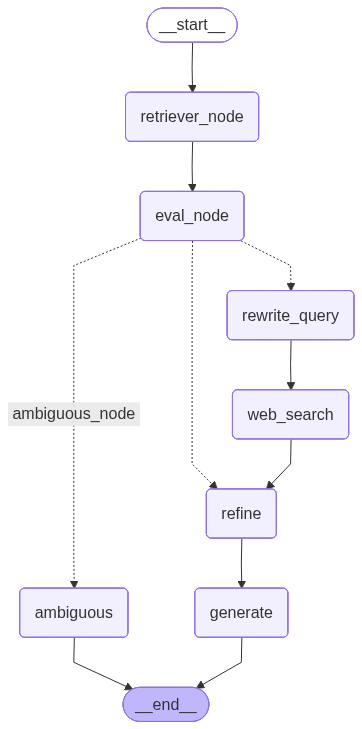

In [34]:
g = StateGraph(State)
g.add_node("retriever_node",retriever_node)
g.add_node('eval_node',eval_each_doc_node)
g.add_node('refine',refine)
g.add_node('web_search',web_search_node)
g.add_node("generate",generate)
g.add_node('ambiguous',ambiguous_node)
g.add_node('rewrite_query',rewrite_query_node)


g.add_edge(START,"retriever_node")
g.add_edge('retriever_node','eval_node')
g.add_conditional_edges(
    'eval_node',
    route_after_eval,
    {'refine':'refine','rewrite_query':'rewrite_query','ambiguous_node':"ambiguous"}
)

g.add_edge('rewrite_query','web_search')
g.add_edge('web_search','refine')
g.add_edge('refine','generate')

g.add_edge('generate',END)
g.add_edge('ambiguous',END)

app = g.compile()

app

In [35]:
res = app.invoke({"question": "what is AI News latest"})

In [36]:
print("VERDICT:",res['verdict'])

VERDICT: INCORRECT


In [37]:
print(res["answer"])

I don't Know based on the provided book.


In [38]:
print(res['web_docs'])

[Document(metadata={'url': 'https://www.ibm.com/think/news/ai-tech-trends-predictions-2026', 'title': 'The trends that will shape AI and tech in 2026 | IBM'}, page_content='TITLE: The trends that will shape AI and tech in 2026 | IBM \n URL: https://www.ibm.com/think/news/ai-tech-trends-predictions-2026 \n CONTENT: \n After much skepticism around AI’s ROI, AI capabilities will pave new ways to do business in the enterprise. And open-source reasoning models and agents will keep pushing boundaries to conquer enterprise AI.\n\nAt the same time, trust and security will become key priorities as many enterprises sharpen their focus on AI sovereignty.\n\nThat’s just the opening act for what’s to come in enterprise tech in the days ahead. Read on for 18 expert predictions to watch out for in 2026.\n\n## The latest AI trends, brought to you by experts\n\nGet curated insights on the most important—and intriguing—AI news. Subscribe to our weekly Think newsletter. See the IBM Privacy Statement.\n\n

In [39]:
print(res['web_query'])

latest AI News
